# Random Forest

Implementing Random Forest Classifier, which has already shown strong performance (~91%) in preliminary trials.

In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
import seaborn as sns
from metrics_utils import calculate_business_metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

mlflow.set_experiment("Walmart-Sales-Classification")

<Experiment: artifact_location='file:///home/sarah/code/forth_year/data_science/project/walmart-sales-classification/src/models/mlruns/810253398722391848', creation_time=1777489467114, experiment_id='810253398722391848', last_update_time=1777489467114, lifecycle_stage='active', name='Walmart-Sales-Classification', tags={}>

In [2]:
train_df = pd.read_csv("../../data/model_ready/train.csv")
test_df = pd.read_csv("../../data/model_ready/test.csv")

features_selected = [
    "Size",
    "Store",
    "Dept",
    "CPI",
    "DeptFrequency",
    "Week_cos",
    "IsPreHoliday",
    "Week_sin",
    "Fuel_Price",
    "ConsumerConfRatio",
    "AvgMarkDownAmount",
]
target = "Sales_Class"
holiday_col = "IsHoliday"

X_train = train_df[features_selected]
y_train = train_df[target]
X_test = test_df[features_selected]
y_test = test_df[target]
test_holidays = test_df[holiday_col]

In [3]:
with mlflow.start_run(run_name="Random_Forest"):
    model_path = "rf_model.pkl"
    if os.path.exists(model_path):
        with open(model_path, "rb") as f:
            model = pickle.load(f)

        print("Model loaded from pickle")
    else:
        params = {"n_estimators": 200, "max_depth": None, "min_samples_split": 5, "random_state": 42}
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        with open(model_path, "wb") as f:
            pickle.dump(model, f)
        print("Model trained and saved to pickle")

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    biz_metrics = calculate_business_metrics(y_test, y_pred, test_holidays)

    mlflow.log_param("model_type", "RandomForest")
    if "params" in locals():
        mlflow.log_params(params)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_weighted", f1)
    mlflow.log_metric("holiday_accuracy", biz_metrics["holiday_accuracy"])
    mlflow.log_metric("weighted_classification_error", biz_metrics["weighted_classification_error"])

    mlflow.log_artifact(model_path)

    print(f"Accuracy: {acc:.4f}")
    print(f"Holiday Accuracy: {biz_metrics['holiday_accuracy']:.4f}")
    print(f"Weighted Error: {biz_metrics['weighted_classification_error']:.4f}")

Model loaded from pickle
Accuracy: 0.9288
Holiday Accuracy: 0.8987
Weighted Error: 0.0959


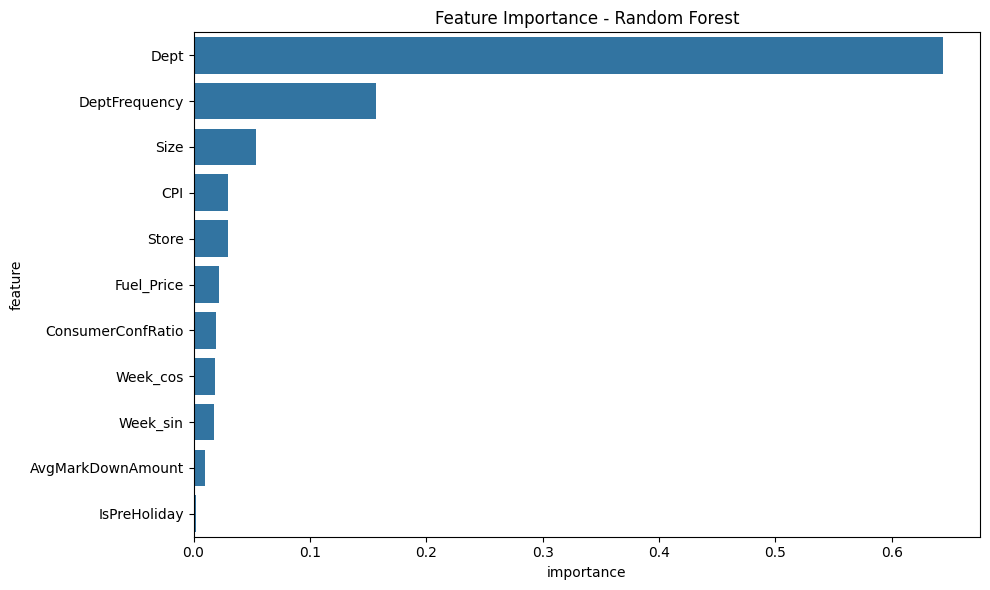

In [4]:
importances = model.feature_importances_
feature_names = features_selected
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
mlflow.log_artifact("feature_importance.png")
plt.show()